# Tumor-coupling experiment (3D monolayer) — analysis

This notebook reads the **archived simulation data** written by `tumor_coupling_3d.py`
and reproduces the matplotlib analyses that used to be baked into the run script:

* a **3-D still** of the tumor's apical surface (one polygon per cell, coloured by
  `cell_type`),
* the **cell population over time** (by type), and
* a comparison of the **internal SBML population ODE** with the realised **tissue**
  cell counts.

The run's `outputs/monolayer_tumor_history.hf5` (the archived apical tissue) is
reopened, and the internal SBML trajectory is read from
`outputs/sbml_population_3d.csv` — so you can re-analyse without re-simulating. The
**interactive ipyvolume 3-D viewer** lives in the companion
`tumor_coupling_3d_viz.ipynb`, which reads the same archive.

Run from the repo's **`vivarium-tyssue` conda env**.

## How the coupling works

Two models run side by side and are coupled one way: a **continuum tumour-population
ODE** (COPASI / SBML) sets the *rates*, and a **3-D volumetric vertex model** (tyssue
monolayer) carries out the resulting discrete cell events.

### Mechanics — 3-D monolayer vertex model

Cells are volumetric polyhedra $\alpha$ with volume $V_\alpha$; their faces $\phi$
have area $A_\phi$ and perimeter $P_\phi$, and edges $\langle ij\rangle$ have
length $\ell_{ij}$. The energy is

$$
E \;=\; \sum_{\alpha} \frac{K_V}{2}\left(V_\alpha - V_{0,\alpha}\right)^2
   \;+\; \sum_{\phi}\left[\frac{K_A}{2}\left(A_\phi - A_0\right)^2
   \;+\; \frac{K_P}{2}\,P_\phi^{2}\right]
   \;+\; \frac{1}{2}\sum_{\langle ij\rangle}\Lambda_{ij}\,\ell_{ij},
$$

(cell-volume elasticity, face-area elasticity, face contractility and line tension),
relaxed in the overdamped limit

$$
\eta\,\frac{\mathrm{d}\mathbf{r}_i}{\mathrm{d}t} \;=\; -\frac{\partial E}{\partial \mathbf{r}_i},
$$

with a forward-Euler step $\Delta t$ and T1 neighbour swaps below $\ell_{\min}$ (so
the confluent tissue can rearrange around a growing cell). Note the **volume** term:
this is the 3-D analogue of the flat sheet's area term, and $V_{0,\alpha}$ (the
per-cell preferred volume) is the handle each division pulls on.

### Tumour-population ODE

`BIOMD0000000903` is integrated by COPASI on its own clock, which advances at
$\alpha$ times the tyssue clock,

$$
t_{\mathrm{ODE}} \;=\; \alpha\, t ,
$$

so $\alpha < 1$ slows the tumour biology relative to the mechanics, spreading
divisions over more mechanical-relaxation times. Each step it yields a reaction flux
$J_k$ for every birth / death channel $k$ (tumour, healthy, stem).

### Coupling — fluxes to discrete events

Fluxes are converted into whole cell events by a **fractional accumulator** per
channel: with a per-channel scale $s_k$,

$$
a_k(t+\Delta t) \;=\; a_k(t) \;+\; \max\bigl(J_k, 0\bigr)\, s_k\, \Delta t ,
\qquad
n_k \;=\; \bigl\lfloor a_k(t+\Delta t) \bigr\rfloor ,
$$

$n_k$ events fire this step and the remainder $a_k - n_k$ is carried forward — so no
event is lost to rounding and a channel with a small flux still fires, eventually.
Births pick cells nearest the tissue centroid (so a seeded focus grows as one compact
mass); deaths pick at random. The focus is seeded as **cancer stem cells** (matching
the SBML model's nonzero initial stem population): they self-renew and commit their
first cell to tumor (C$\rightarrow$T), and the bulk tumor then grows by division.

Each birth is executed as a real division: the cell's preferred **volume** grows,

$$
V_0(t+\Delta t) \;=\; V_0(t)\,\bigl(1 + g\,\Delta t\bigr),
\qquad \text{split once } V > V_c ,
$$

with the division-plane orientation randomised between *vertical* (in-plane) and
*horizontal* (stacking a daughter in $z$), which is what turns the clone into a
genuine 3-D mass rather than a flat patch. Deaths shrink $V_0$ at rate $s$ until the
cell is marked dead / necrotic (volumetric extrusion is numerically fragile in 3-D,
so dead cells are kept in the mesh and coloured black).

### Parameters

### Rigidity limits the 3-D mass

Unlike the flat sheet, a confluent 3-D monolayer is **volumetrically jammed**: a
cell cannot freely enlarge because its neighbours fill space and resist, so a
committed cell often cannot reach its division volume and the clone stops growing.
In vertex-model rigidity theory the tissue is **solid below** a preferred 3-D shape
index $s_0 = S_0 V_0^{-2/3} \approx 5.4$ and **fluid above** it, where cells
rearrange (T1 neighbour swaps) and divisions find room (Azote & Manning, *3D vertex
models of stratified epithelia*, 2025; cancer tissue sits on the fluid side, Grosser
*et al.*, PRX 2020). We nudge the basal layer toward that fluid regime with a small
T1-reconnection bump (`threshold_length` 0.03 → 0.05; tyssue’s monolayer topology
corrupts above ~0.1, so this is as fluid as it stays numerically stable). Necrotic
**death is switched off** (`tumor_deaths = stem_deaths = 0`) so the clone is not
eroded. The result: the tumour grows by real divisions and then **holds at a stable,
mechanics-limited size** — in contrast to the non-spatial ODE, whose tumour
population keeps climbing (the SBML-vs-tissue panel below shows this divergence).

| symbol | meaning | code / value |
|---|---|---|
| $K_V,\;V_0$ | cell volume elasticity, preferred volume | `VOL_ELASTICITY` = 1.0, `PREFERRED_VOL` = 1.0 |
| $K_A,\;A_0$ | face area elasticity, preferred area | `AREA_ELASTICITY` = 1.0, `PREFERRED_AREA` = 1.0 |
| $K_P$ | face contractility | `CONTRACTILITY` = 0.05 |
| $\Lambda$ | line tension | `LINE_TENSION` = 0.0 |
| $\eta$ | vertex friction | `VISCOSITY` = 1.0 |
| $\alpha$ | ODE-to-tissue clock ratio | `COPASI_TIME` = 1.0 |
| $s_k$ | flux $\rightarrow$ event scales | `SCALES` (e.g. `tumor_births` = 3e−6) |
| $g,\;V_c$ | growth rate, division volume | `growth_rate` = 1.0, `division_crit` = 2.0 |
| $\Delta t,\;T$ | solver step, total time | `TUMOR_DT` = 0.1, `TUMOR_TF` = 160.0 |
| — | initial cancer-stem-cell focus | `SEED_STEM` = 6 cells |

(These are the defaults; every knob is a module-level constant in `tumor_coupling_3d.py`.)

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Simulation config is the single source of truth — import it from the sim script.
import tumor_coupling_3d as sim
from tumor_coupling_3d import (
    OUT_DIR, HISTORY_FILE, CELL_TYPE_COLORS, POP_TYPES, SBML_SPECIES,
    SEED_STEM, BIRTH_FLUXES, DEATH_FLUXES,
)

sys.path.insert(0, str(sim.REPO))   # so tyssue imports cleanly if needed

FIG_DPI = 300
SBML_CSV = OUT_DIR / "sbml_population_3d.csv"

print("archive:", HISTORY_FILE)

archive: /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/tumor_coupling/outputs/monolayer_tumor_history.hf5


## The composite bigraph

The 3-D run has the same two-process shape as the 2-D one: the `EulerSolver` process
(`Tyssue`) integrating the **monolayer** vertex model, and `TumorCoupling`, which
steps the COPASI/SBML population ODE internally and converts its fluxes into
volumetric division / apoptosis events. They are coupled only through the shared
**stores** — `TumorCoupling` reads `Tissue State` (the tyssue `vert` / `edge` / `face` /
`cell` dataframes) and `global_time` and writes `Behaviors`; the solver executes
those events and reports back through `Tissue State` and `Network Changed`.

`bigraph_viz` draws the wiring below in the style of `Notebooks/simulation_walkthrough.ipynb`, with the manuscript palette:
**processes are boxes in peach / pink**, **stores are circles in light blue**
(defined once in `Experiments/bigraph_style.py`). Every spec comes straight
from the simulation script, so the diagram cannot drift from what was run;
the PNGs are written to `outputs/bigraphs/`.

(`TumorCoupling` also *declares* per-species count / flux output ports that this spec
leaves unwired; they are hidden here — pass `show_unwired_ports=True` to draw them.)

In [2]:
sys.path.insert(0, str(sim.REPO / "Experiments"))   # shared bigraph palette
from bigraph_style import plot_experiment_bigraph
from vivarium_tyssue.core import build_core

core = build_core()                    # the same core the simulation runs on
mesh = sim.ensure_dataset("monolayer_box.hf5", sim.MONO_SRC)
model = sim.ensure_dataset(sim.SBML_MODEL,
                           sim.REPO / "workspace" / "datasets" / sim.SBML_MODEL)
plot_experiment_bigraph(sim.build_tumor_spec(mesh, model), core=core,
                        filename="tumor_coupling_3d_bigraph",
                        out_dir=OUT_DIR / "bigraphs")

skipping `process_bigraph.server.rest` (missing optional dep `fastapi_utils`)


module `pbg_emitters.xarray_emitter` not found during dynamic import


/Users/tasnifrahman/PycharmProjects/vivatyssue/src/tyssue/core/objects.py:291: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  self.cell_df["num_faces"] = self.edge_df.groupby("cell").apply(


wrote /Users/tasnifrahman/PycharmProjects/vivarium-tyssue/Experiments/tumor_coupling/outputs/bigraphs/tumor_coupling_3d_bigraph.png


## Loading the archived history

The simulation archives the monolayer's **apical surface** (one polygon per cell,
each stamped with its cell's `cell_type`) plus the per-cell table, as long-format
HDF5 tables with a `time` column and a positional index column per element. The
analysis works directly from those stacked dataframes — population counts from the
`cell` table, the 3-D still from the `vert` / `edge` / `face` tables — so no full
tyssue object needs rebuilding.

In [3]:
class LoadedHistory:
    # Stacked archive tables (one `time` column per row); .datasets for analysis,
    # .frame(t, elem) for the per-frame element dataframe used by the 3-D still.
    def __init__(self, path):
        with pd.HDFStore(str(path), "r") as store:
            self.datasets = {k.strip("/"): store.select(k) for k in store.keys()}
        ref = self.datasets.get("cell", self.datasets["vert"])
        self._times = np.array(sorted(ref["time"].unique()))

    @property
    def time_stamps(self):
        return self._times

    def frame(self, t, elem):
        # Rows of `elem` at the nearest recorded time (still in positional order).
        t = self._times[int(np.argmin(np.abs(self._times - t)))]
        df = self.datasets[elem]
        return df[df["time"] == t].reset_index(drop=True)


def load_sbml(path) -> pd.DataFrame:
    # The internal SBML trajectory written live during the run (species + fluxes).
    path = Path(path)
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

## 3-D still — apical tumor surface

A static counterpart to the interactive `browse_history` view: the apical surface at
the final frame, each cell's polygon filled by its `cell_type`
(**healthy = blue**, **tumor = red**, **stem = purple**, **dead = black**). The
seeded focus has grown outward — and, thanks to the randomised division orientation,
upward in $z$ — into a compact 3-D clone.

In [4]:
def _apical_polygons(vert_df, edge_df, face_df):
    # (polygons, colors): each apical face's vertex-ring polygon, coloured by its
    # cell_type. srce / face are POSITIONAL row indices (archived that way).
    vpos = vert_df[["x", "y", "z"]].to_numpy()
    ftype = face_df["cell_type"].astype(str).to_numpy()
    polys, colors = [], []
    for face, grp in edge_df.groupby("face"):
        ring = grp["srce"].to_numpy()
        if len(ring) < 3:
            continue
        polys.append(vpos[ring])
        colors.append(CELL_TYPE_COLORS.get(str(ftype[int(face)]), "#cccccc"))
    return polys, colors


def plot_still_3d(history, out_path: Path, t=None):
    times = list(history.time_stamps)
    if not times:
        return
    t = float(times[-1]) if t is None else float(t)
    polys, colors = _apical_polygons(history.frame(t, "vert"),
                                     history.frame(t, "edge"),
                                     history.frame(t, "face"))
    v = history.frame(t, "vert")
    fig = plt.figure(figsize=(7.5, 6.0))
    ax = fig.add_subplot(111, projection="3d")
    ax.add_collection3d(Poly3DCollection(polys, facecolors=colors,
                                         edgecolors="#555555", linewidths=0.3, alpha=0.95))
    ax.set_xlim(v["x"].min(), v["x"].max()); ax.set_ylim(v["y"].min(), v["y"].max())
    ax.set_zlim(v["z"].min() - 0.5, v["z"].max() + 0.5)
    ax.set_title(f"3D monolayer tumor (apical surface) — t = {t:.1f}", fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    seen = [k for k in CELL_TYPE_COLORS
            if k in set(map(str, history.frame(t, "face")["cell_type"].unique()))]
    ax.legend(handles=[Patch(facecolor=CELL_TYPE_COLORS[k], edgecolor="#808080", label=k)
                       for k in seen],
              loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()

## Population over time

Cell counts by `cell_type` at each archived frame, from the per-cell table. Dead
cells (`is_alive = 0`) keep their `dead` type, so they are counted too. The seeded
tumor clone grows while healthy cells are displaced.

In [5]:
def population_over_time(history) -> pd.DataFrame:
    # Count of each cell type at every recorded timepoint (wide: time x types).
    cell = history.datasets["cell"]
    counts = cell.groupby(["time", "cell_type"]).size().unstack(fill_value=0)
    return counts.reindex(sorted(counts.index)).reset_index()


def plot_population_over_time(counts: pd.DataFrame, out_path: Path):
    fig, ax = plt.subplots(figsize=(8.0, 4.4))
    for t in [t for t in POP_TYPES if t in counts.columns]:
        ax.plot(counts["time"], counts[t].to_numpy(), "-", linewidth=1.9,
                color=CELL_TYPE_COLORS[t], label=t)
    for t in ("dividing", "extruding"):
        if t in counts.columns and counts[t].to_numpy().max() > 0:
            ax.plot(counts["time"], counts[t].to_numpy(), ":", linewidth=1.0,
                    color=CELL_TYPE_COLORS[t], label=t, alpha=0.8)
    total = counts[[c for c in counts.columns if c != "time"]].sum(axis=1)
    ax.plot(counts["time"], total.to_numpy(), "--", linewidth=1.3,
            color="#555555", label="total (all types)")
    ax.set_xlabel(r"$t$"); ax.set_ylabel(r"$N$")
    ax.set_title("Tumor coupling (3D monolayer): cell population over time", fontsize=11)
    ax.margins(x=0); ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=9)
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()

## Internal SBML model vs tissue

The tumour ODE runs autonomously inside `TumorCoupling` (the tissue feeds nothing
back into it), so the recorded SBML trajectory is the exact driver of the tissue
events. The tissue is a **scaled, mechanically throttled discrete realisation** of
that flux-driven process — a confluent monolayer can only complete so many divisions
— so absolute magnitudes differ; the meaningful check is whether the trajectories
**track**. The SBML species are interpolated onto the tissue timeline and correlated
with the matching tissue counts (tumour-lineage = `tumor` + `dividing`; `healthy`),
and per-population fold-changes are compared.

In [6]:
def _tissue_series(counts: pd.DataFrame, *cols) -> np.ndarray:
    total = np.zeros(len(counts))
    for c in cols:
        if c in counts.columns:
            total = total + counts[c].to_numpy(dtype=float)
    return total


def _interp_species(sbml_df, sid, t):
    col = f"species_{sid}"
    if col not in sbml_df.columns:
        return np.zeros_like(t)
    return np.interp(t, sbml_df["time"].to_numpy(), sbml_df[col].to_numpy())


def compare_sbml_tissue(sbml_df: pd.DataFrame, counts: pd.DataFrame):
    t = counts["time"].to_numpy(dtype=float)
    tumor = _tissue_series(counts, "tumor", "dividing")
    healthy = _tissue_series(counts, "healthy")
    T = _interp_species(sbml_df, "T", t)
    H = _interp_species(sbml_df, "H", t)

    def corr(a, b):
        if len(a) < 2 or a.std() == 0 or b.std() == 0:
            return float("nan")
        return float(np.corrcoef(a, b)[0, 1])

    def model_fold(sid):
        col = f"species_{sid}"
        if col not in sbml_df.columns or sbml_df[col].iloc[0] == 0:
            return float("nan")
        return float(sbml_df[col].iloc[-1] / sbml_df[col].iloc[0])

    aligned = pd.DataFrame({"time": t, "tumor_tissue": tumor, "healthy_tissue": healthy,
                            "T_model": T, "H_model": H})
    metrics = {
        "corr_tumor": corr(tumor, T),
        "corr_healthy": corr(healthy, H),
        "fold_tumor_tissue": float(tumor[-1] / SEED_STEM) if SEED_STEM else float("nan"),
        "fold_tumor_model": model_fold("T"),
        "fold_healthy_tissue": float(healthy[-1] / healthy[0]) if len(healthy) and healthy[0] else float("nan"),
        "fold_healthy_model": model_fold("H"),
        "tumor_end": float(tumor[-1]) if len(tumor) else 0.0,
    }
    return aligned, metrics


def plot_sbml_and_comparison(sbml_df, counts, aligned, metrics, out_path: Path):
    fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))

    axA = axes[0]   # (A) internal SBML populations, normalized to their initial amount
    for sid in ("T", "H", "C"):
        col = f"species_{sid}"
        if col in sbml_df.columns:
            y = sbml_df[col].to_numpy(float)
            y0 = y[0] if len(y) and y[0] != 0 else 1.0
            axA.plot(sbml_df["time"], y / y0, lw=1.8,
                     color=CELL_TYPE_COLORS[SBML_SPECIES[sid]],
                     label=f"{SBML_SPECIES[sid]} ({sid}, init {y[0]:.2g})")
    axA.set_title("SBML model populations (normalized to t=0)", fontsize=10)
    axA.set_xlabel("model time"); axA.set_ylabel("amount / amount(0)")
    axA.grid(alpha=0.25); axA.legend(frameon=False, fontsize=8)

    axB = axes[1]   # (B) tissue cell counts
    axB.plot(counts["time"], _tissue_series(counts, "tumor", "dividing"),
             color=CELL_TYPE_COLORS["tumor"], lw=1.9, label="tumor (incl. dividing)")
    axB.plot(counts["time"], _tissue_series(counts, "healthy"),
             color=CELL_TYPE_COLORS["healthy"], lw=1.6, label="healthy")
    dead = _tissue_series(counts, "dead", "extruding")
    if dead.max() > 0:
        axB.plot(counts["time"], dead, color=CELL_TYPE_COLORS["dead"], lw=1.2, label="dead")
    axB.set_title("Tissue cell counts", fontsize=10)
    axB.set_xlabel("time"); axB.set_ylabel("cell count")
    axB.grid(alpha=0.25); axB.legend(frameon=False, fontsize=8)

    axC = axes[2]   # (C) normalized tumor growth: model vs tissue
    if "species_T" in sbml_df.columns and sbml_df["species_T"].iloc[0] != 0:
        axC.plot(sbml_df["time"], sbml_df["species_T"] / sbml_df["species_T"].iloc[0],
                 color=CELL_TYPE_COLORS["tumor"], lw=1.8, label=r"model tumor $T/T_0$")
    axC.plot(aligned["time"], aligned["tumor_tissue"] / SEED_STEM, "o-", ms=3,
             color="#333333", lw=1.1, label="tissue tumor / seed")
    axC.set_title("Tumor growth: model vs tissue (normalized)", fontsize=10)
    axC.set_xlabel("time"); axC.set_ylabel("fold-change from start")
    txt = (f"corr(tumor, T) = {metrics['corr_tumor']:.2f}\n"
           f"corr(healthy, H) = {metrics['corr_healthy']:.2f}\n"
           f"tumor fold: tissue x{metrics['fold_tumor_tissue']:.2f} / "
           f"model x{metrics['fold_tumor_model']:.2f}")
    axC.text(0.03, 0.97, txt, transform=axC.transAxes, va="top", ha="left", fontsize=8.5,
             bbox=dict(boxstyle="round", fc="white", ec="#cccccc", alpha=0.9))
    axC.grid(alpha=0.25); axC.legend(frameon=False, fontsize=8, loc="lower right")

    fig.suptitle("3D tumor coupling - internal SBML model vs tissue population", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight"); plt.show()

## Run — still, population & SBML comparison

loaded 60 frames


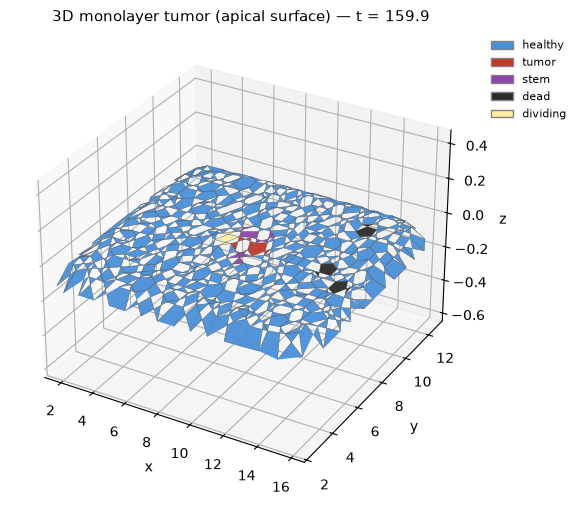

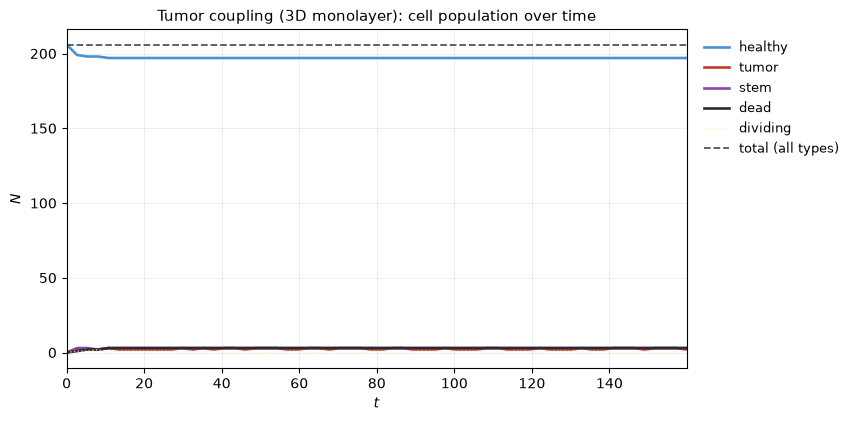

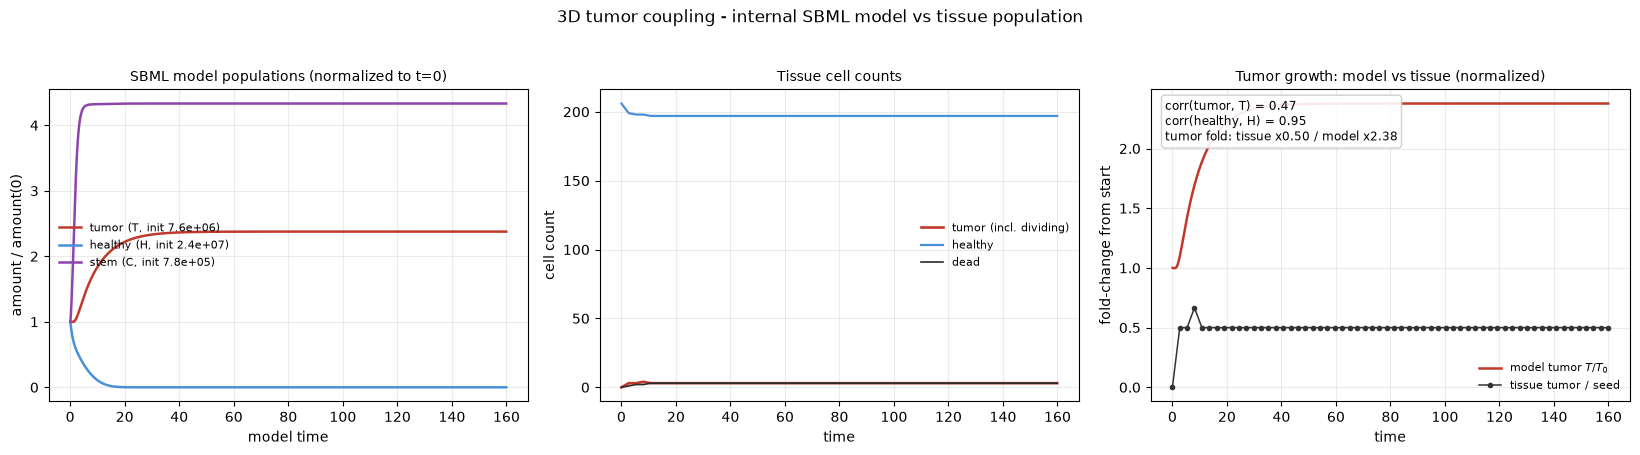

[tumor3d] tumor fold: model x2.38 vs tissue x0.50 (corr=0.47); healthy corr=0.95
[tumor3d] population start {'healthy': 206, 'tumor': 0, 'stem': 0, 'dead': 0} -> end {'healthy': 197, 'tumor': 2, 'stem': 3, 'dead': 3}
[tumor3d] cells 206 -> 206


In [7]:
if not HISTORY_FILE.exists():
    print("no archive — run `python tumor_coupling_3d.py` first")
else:
    hist = LoadedHistory(HISTORY_FILE)
    print(f"loaded {len(list(hist.time_stamps))} frames")

    plot_still_3d(hist, OUT_DIR / "tumor_still_3d.png")

    counts = population_over_time(hist)
    counts.to_csv(OUT_DIR / "population_over_time_3d.csv", index=False)
    plot_population_over_time(counts, OUT_DIR / "population_over_time_3d.png")

    sbml_df = load_sbml(SBML_CSV)
    if not sbml_df.empty:
        aligned, metrics = compare_sbml_tissue(sbml_df, counts)
        plot_sbml_and_comparison(sbml_df, counts, aligned, metrics,
                                 OUT_DIR / "sbml_vs_tissue_3d.png")
        print(f"[tumor3d] tumor fold: model x{metrics['fold_tumor_model']:.2f} vs "
              f"tissue x{metrics['fold_tumor_tissue']:.2f} (corr={metrics['corr_tumor']:.2f}); "
              f"healthy corr={metrics['corr_healthy']:.2f}")
    else:
        print(f"no {SBML_CSV.name} — SBML comparison skipped")

    start, end = counts.iloc[0], counts.iloc[-1]
    fmt = lambda row: {t: int(row[t]) for t in POP_TYPES if t in counts.columns}
    print(f"[tumor3d] population start {fmt(start)} -> end {fmt(end)}")
    print(f"[tumor3d] cells {int(counts.iloc[0].drop('time').sum())} -> "
          f"{int(counts.iloc[-1].drop('time').sum())}")